<a href="https://colab.research.google.com/github/bheemeshpujari63/user-segmentation/blob/main/User_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Code 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_excel('/content/Online Retail.xlsx')
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
data.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
357771,568134,22107,PIZZA PLATE IN BOX,1,2011-09-23 17:02:00,3.29,NaN,United Kingdom
5155,536846,22625,RED KITCHEN SCALES,1,2010-12-02 19:59:00,8.50,14573.0,United Kingdom
197659,553923,21395,BLUE POLKADOT BEAKER,96,2011-05-20 09:30:00,0.39,13266.0,United Kingdom
429824,573576,22666,RECIPE BOX PANTRY YELLOW DESIGN,1,2011-10-31 14:09:00,5.79,14096.0,United Kingdom
168027,551010,22078,RIBBON REEL LACE DESIGN,1,2011-04-26 09:52:00,4.71,NaN,United Kingdom


In [ ]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
def clean_selldata(df):
    # Remove rows without CustomerID
    df = df.dropna(subset=["CustomerID"])

    # Remove returns (negative or zero quantity)
    df = df[df["Quantity"] > 0]

    # Remove invalid prices
    df = df[df["UnitPrice"] > 0]

    # Create total transaction value
    df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

    # Convert InvoiceDate to datetime
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    return df

In [ ]:
data_sell = clean_selldata(data)
data_sell

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [ ]:
snapshot_date = data_sell["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
rfm = data_sell.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,91.720609,2054.266460
std,100.014169,228.785094,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,307.415000
50%,51.000000,41.000000,674.485000
75%,142.000000,100.000000,1661.740000
max,374.000000,7847.000000,280206.020000


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=rfm.columns
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.396578,8.358668
12347.0,-0.905340,0.394649,0.250966
12348.0,-0.175360,-0.265435,-0.028596
12349.0,-0.735345,-0.081836,-0.033012
12350.0,2.174578,-0.326635,-0.191347


In [ ]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-3.965777e-01,-2.281344e-01
25%,-7.453445e-01,-3.266350e-01,-1.943495e-01
50%,-4.153533e-01,-2.217210e-01,-1.535104e-01
75%,4.946227e-01,3.619268e-02,-4.367134e-02
max,2.814561e+00,3.390157e+01,3.094634e+01


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)


KMeans(n_clusters=4, random_state=42)

In [ ]:
rfm["Cluster"] = kmeans.labels_
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,1
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,3


In [ ]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,2171
1,1326
3,828
2,13


In [ ]:
cluster_summary = rfm.groupby("Cluster").mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,20.990788,135.285122,2645.818172
1,98.218703,37.719457,773.877083
2,4.692308,2565.307692,126118.310000
3,272.407005,25.138889,605.842525


In [ ]:
cluster_labels = {
    0: "High-Value Loyal Customers",
    1: "Churn Risk Customers",
    2: "New / Low Engagement Customers",
    3: "Regular Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Regular Customers
12347.0,2,182,4310.00,0,High-Value Loyal Customers
12348.0,75,31,1797.24,1,Churn Risk Customers
12349.0,19,73,1757.55,0,High-Value Loyal Customers
12350.0,310,17,334.40,3,Regular Customers


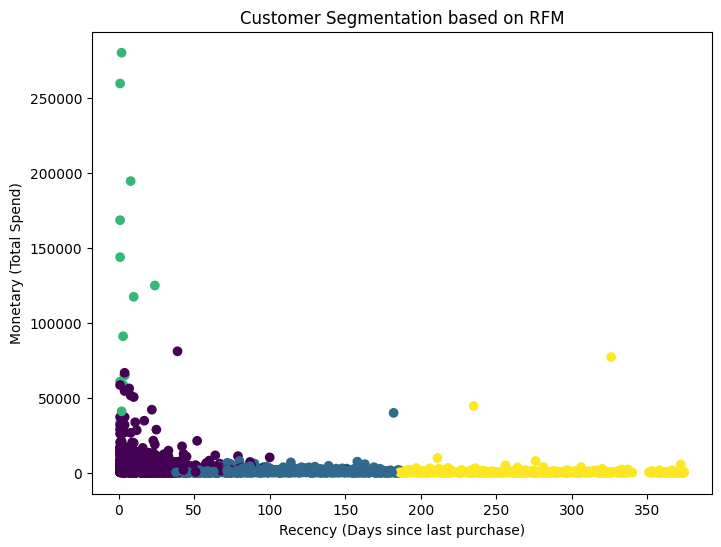

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Recency (Days since last purchase)")
plt.ylabel("Monetary (Total Spend)")
plt.title("Customer Segmentation based on RFM")
plt.show()

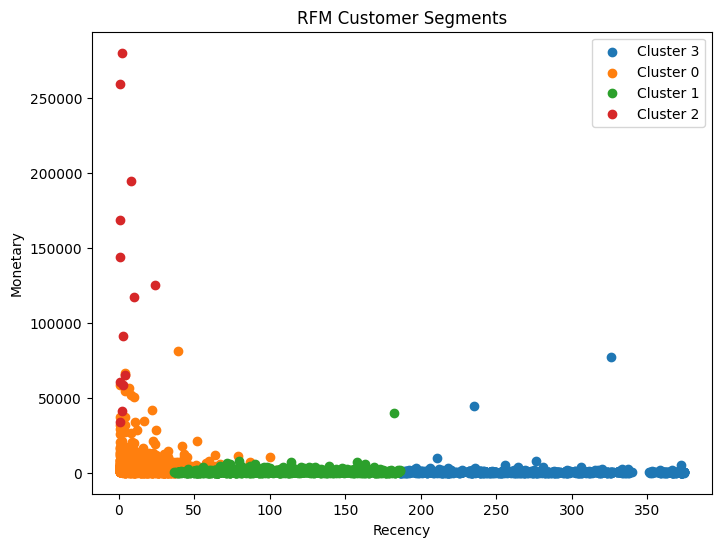

In [ ]:
plt.figure(figsize=(8, 6))

for cluster in rfm["Cluster"].unique():
    subset = rfm[rfm["Cluster"] == cluster]
    plt.scatter(
        subset["Recency"],
        subset["Monetary"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("RFM Customer Segments")
plt.legend()
plt.show()

#Code 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

Libraries imported successfully
Analysis Date: 2026-01-17


In [3]:
data = pd.read_excel("/content/Online Retail.xlsx")

In [4]:
print("=" * 80)
print("📦 DATASET LOADED SUCCESSFULLY")
print("=" * 80)
print(f"Total Rows: {len(data):,}")
print(f"Total Columns: {len(data.columns)}")
print(f"\nDate Range: {data['InvoiceDate'].min()} to {data['InvoiceDate'].max()}")
print(f"Countries: {data['Country'].nunique()}")

📦 DATASET LOADED SUCCESSFULLY
Total Rows: 541,909
Total Columns: 8

Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Countries: 38


In [5]:
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.00,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.00,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.00,United Kingdom


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [8]:
# Missing values
print("\n4️⃣ Missing Values:")
missing_stats = pd.DataFrame({
    'Column': data.columns,
    'Missing_Count': data.isnull().sum().values,
    'Missing_Percentage': (data.isnull().sum().values / len(data) * 100).round(2)
})
print(missing_stats[missing_stats['Missing_Count'] > 0])


4️⃣ Missing Values:
        Column  Missing_Count  Missing_Percentage
2  Description           1454                0.27
6   CustomerID         135080               24.93


In [11]:
# Unique values
print("\n Unique Value Counts:")
for col in data.columns:
    print(f"{col}: {data[col].nunique():,} unique values")


 Unique Value Counts:
InvoiceNo: 25,900 unique values
StockCode: 4,070 unique values
Description: 4,223 unique values
Quantity: 722 unique values
InvoiceDate: 23,260 unique values
UnitPrice: 1,630 unique values
CustomerID: 4,372 unique values
Country: 38 unique values


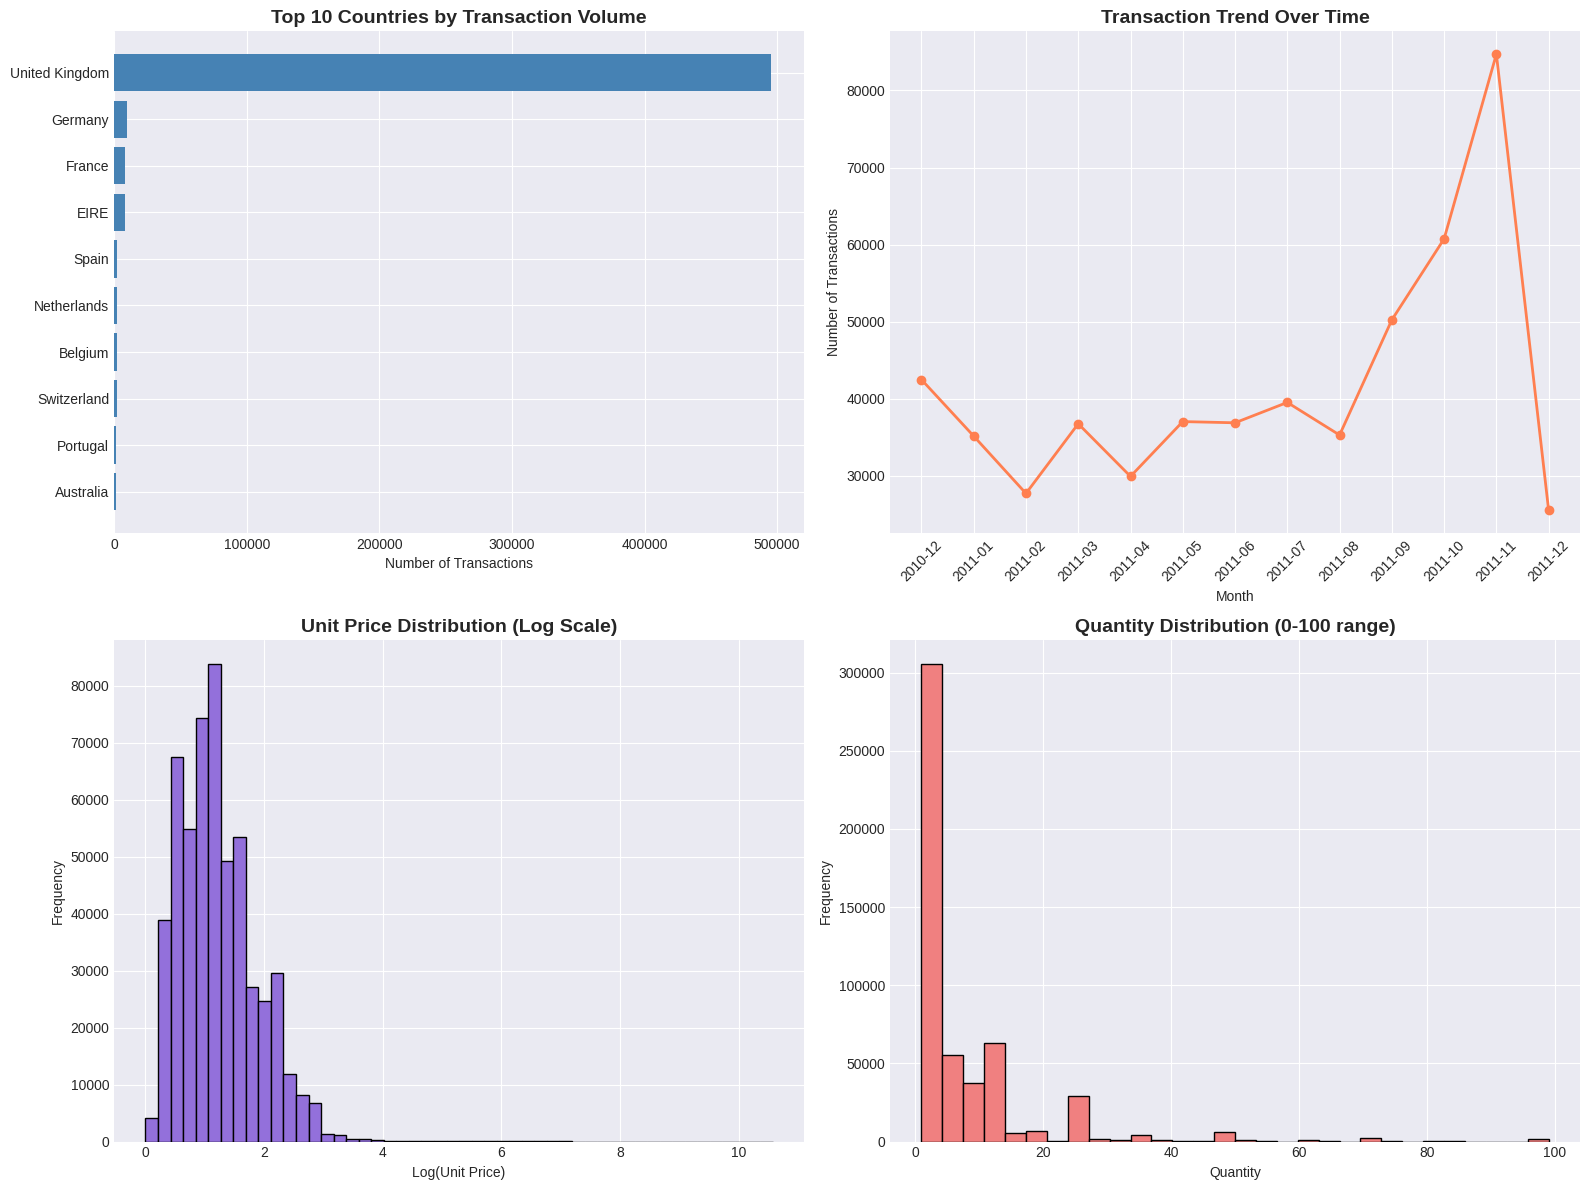

✅ Saved: 01_data_overview.png


In [12]:
# EDA Visualizations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10 Countries by Transaction Volume
top_countries = data['Country'].value_counts().head(10)
axes[0, 0].barh(top_countries.index, top_countries.values, color='steelblue')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_title('Top 10 Countries by Transaction Volume', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. Transactions Over Time
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
monthly_trans = data.groupby(data['InvoiceDate'].dt.to_period('M')).size()
axes[0, 1].plot(monthly_trans.index.astype(str), monthly_trans.values, marker='o', linewidth=2, color='coral')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].set_title('Transaction Trend Over Time', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Price Distribution (log scale)
prices = data[data['UnitPrice'] > 0]['UnitPrice']
axes[1, 0].hist(np.log1p(prices), bins=50, color='mediumpurple', edgecolor='black')
axes[1, 0].set_xlabel('Log(Unit Price)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Unit Price Distribution (Log Scale)', fontsize=14, fontweight='bold')

# 4. Quantity Distribution
quantities = data[(data['Quantity'] > 0) & (data['Quantity'] < 100)]['Quantity']
axes[1, 1].hist(quantities, bins=30, color='lightcoral', edgecolor='black')
axes[1, 1].set_xlabel('Quantity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Quantity Distribution (0-100 range)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 01_data_overview.png")

In [13]:
# ============================================================================
# SECTION 3: DATA CLEANING & PREPROCESSING
# ============================================================================

print("\n" + "=" * 80)
print("🧹 DATA CLEANING & PREPROCESSING")
print("=" * 80)

# Initial record count
initial_rows = len(data)

# Step 1: Remove records without CustomerID
data_clean = data.dropna(subset=['CustomerID']).copy()
print(f"\n Removed {initial_rows - len(data_clean):,} rows without CustomerID")
print(f"   Remaining: {len(data_clean):,} rows")

# Step 2: Remove cancelled/returned orders (negative quantities)
data_clean = data_clean[data_clean['Quantity'] > 0]
print(f"\n Removed returns (negative quantities)")
print(f"   Remaining: {len(data_clean):,} rows")

# Step 3: Remove invalid prices
data_clean = data_clean[data_clean['UnitPrice'] > 0]
print(f"\n Removed invalid prices (≤ 0)")
print(f"   Remaining: {len(data_clean):,} rows")

# Step 4: Filter for UK customers only (as per paper)
data_clean = data_clean[data_clean['Country'] == 'United Kingdom']
print(f"\n Filtered for UK customers only")
print(f"   Remaining: {len(data_clean):,} rows")

# Step 5: Create TotalPrice column
data_clean['TotalPrice'] = data_clean['Quantity'] * data_clean['UnitPrice']
print(f"\n Created TotalPrice column")

# Step 6: Convert CustomerID to integer
data_clean['CustomerID'] = data_clean['CustomerID'].astype(int)

# Step 7: Ensure datetime format
data_clean['InvoiceDate'] = pd.to_datetime(data_clean['InvoiceDate'])

# Summary of cleaned data
print("\n" + "=" * 80)
print(" CLEANED DATASET SUMMARY")
print("=" * 80)
print(f"Total Transactions: {len(data_clean):,}")
print(f"Unique Customers: {data_clean['CustomerID'].nunique():,}")
print(f"Unique Products: {data_clean['StockCode'].nunique():,}")
print(f"Unique Invoices: {data_clean['InvoiceNo'].nunique():,}")
print(f"Total Revenue: £{data_clean['TotalPrice'].sum():,.2f}")
print(f"Average Order Value: £{data_clean.groupby('InvoiceNo')['TotalPrice'].sum().mean():,.2f}")
print(f"Date Range: {data_clean['InvoiceDate'].min().date()} to {data_clean['InvoiceDate'].max().date()}")

# Data quality check
print(f"\n Data Cleaning Complete - Ready for RFM Analysis")
print(f"   Records retained: {len(data_clean)/initial_rows*100:.1f}% of original dataset")


🧹 DATA CLEANING & PREPROCESSING

 Removed 135,080 rows without CustomerID
   Remaining: 406,829 rows

 Removed returns (negative quantities)
   Remaining: 397,924 rows

 Removed invalid prices (≤ 0)
   Remaining: 397,884 rows

 Filtered for UK customers only
   Remaining: 354,321 rows

 Created TotalPrice column

 CLEANED DATASET SUMMARY
Total Transactions: 354,321
Unique Customers: 3,920
Unique Products: 3,645
Unique Invoices: 16,646
Total Revenue: £7,308,391.55
Average Order Value: £439.05
Date Range: 2010-12-01 to 2011-12-09

 Data Cleaning Complete - Ready for RFM Analysis
   Records retained: 65.4% of original dataset



🔧 RFM FEATURE ENGINEERING
Analysis Snapshot Date: 2011-12-10

📊 RFM Dataset Summary:
Total Customers: 3,920

       CustomerID  Recency  Frequency  Monetary  Tenure_Days  AvgOrderValue  OrderValueStd  TotalItems  AvgDaysBetweenPurchases  MonetaryPerFrequency
count     3920.00  3920.00    3920.00   3920.00      3920.00        3920.00        3850.00     3920.00                  3920.00               3920.00
mean     15562.06    92.21       4.25   1864.39       223.55          71.76          53.40     1085.90                    98.45                393.33
std       1576.59    99.53       7.20   7482.82       118.07        1543.98        1608.63     3737.51                    87.41               1869.97
min      12346.00     1.00       1.00      3.75         1.00           2.10           0.00        1.00                     1.00                  3.45
25%      14208.75    18.00       1.00    300.28       112.00          11.19           5.81      154.00                    36.98             

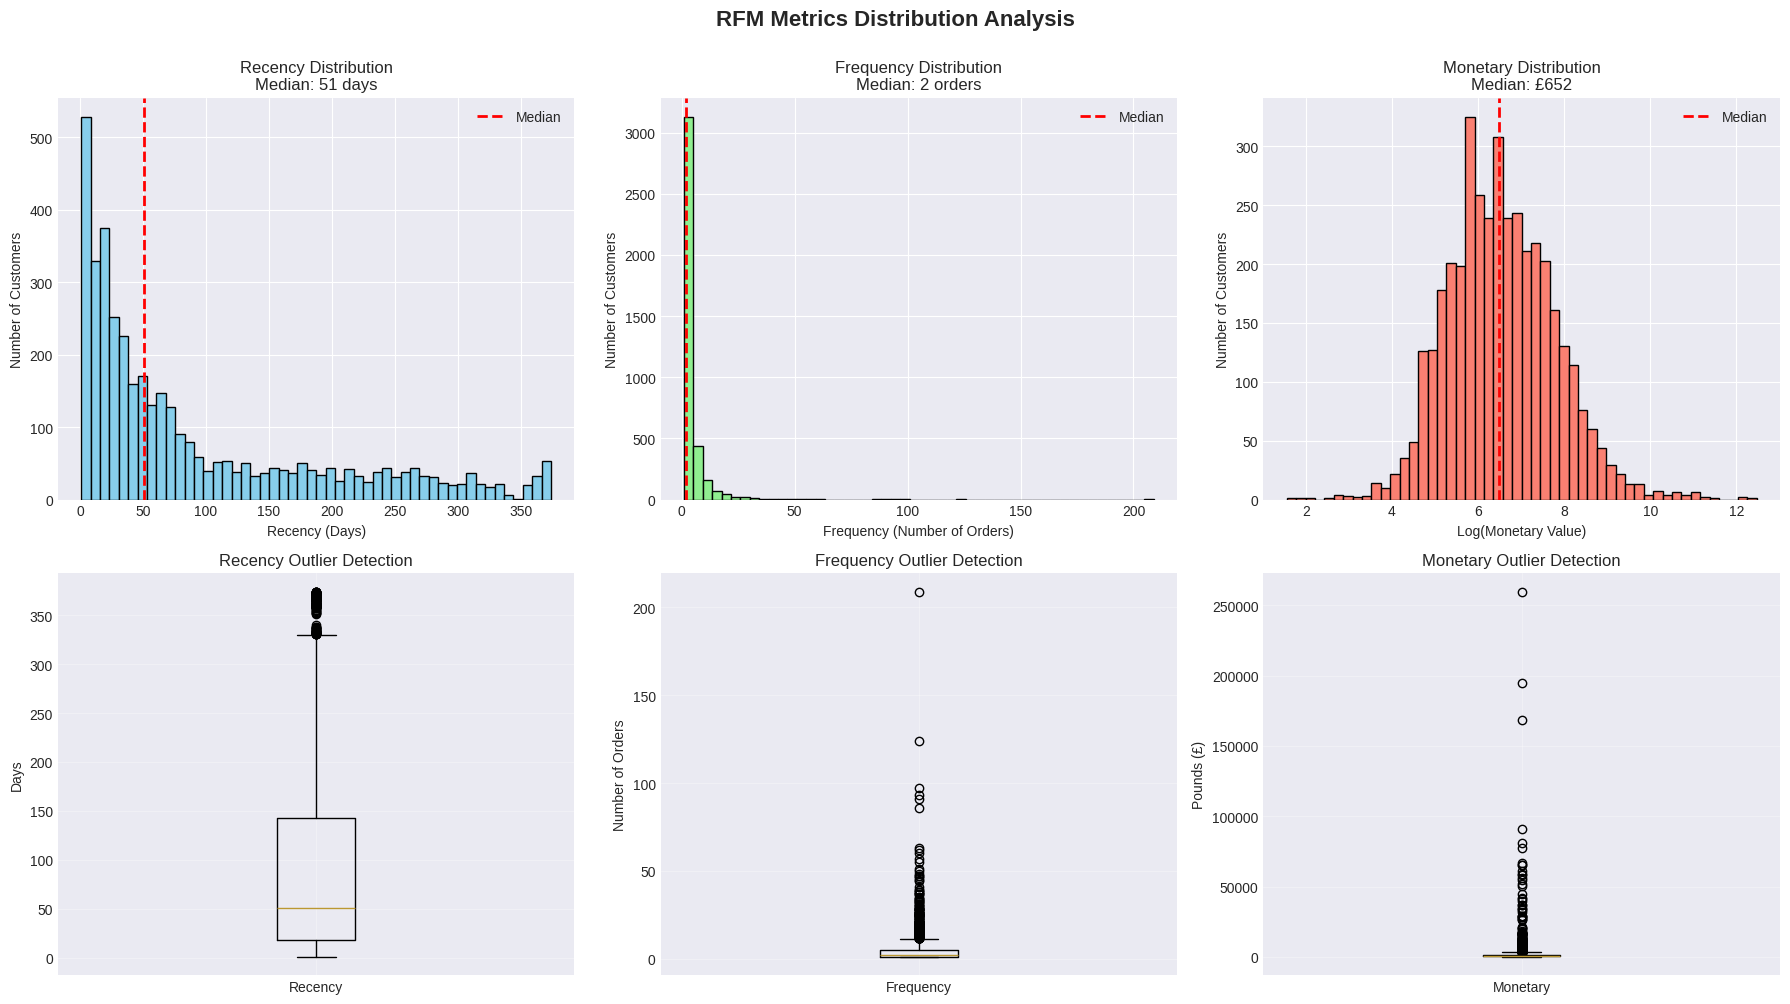

✅ Saved: 02_rfm_distributions.png

🔍 OUTLIER ANALYSIS

Recency:
  Outliers detected: 132 (3.4%)
  Valid range (IQR): [-169.50, 330.50]
  99th percentile: 369.00

Frequency:
  Outliers detected: 261 (6.7%)
  Valid range (IQR): [-5.00, 11.00]
  99th percentile: 29.81

Monetary:
  Outliers detected: 382 (9.7%)
  Valid range (IQR): [-1614.18, 3491.04]
  99th percentile: 17281.16

📌 Applying Paper's Methodology:
   Filtering extreme outliers (top 1% for Frequency and Monetary)

Customers before filtering: 3,920
Customers after filtering: 3,861
Filtered out: 59 extreme outliers (1.5%)


In [14]:
# %%
# ============================================================================
# SECTION 4: RFM FEATURE ENGINEERING
# ============================================================================

print("\n" + "=" * 80)
print("🔧 RFM FEATURE ENGINEERING")
print("=" * 80)

# Define snapshot date (day after last transaction)
snapshot_date = data_clean['InvoiceDate'].max() + timedelta(days=1)
print(f"Analysis Snapshot Date: {snapshot_date.date()}")

# Calculate RFM metrics per customer
rfm = data_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Additional metrics for deeper analysis
additional_metrics = data_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.min()).days,  # Customer Tenure
    'TotalPrice': ['mean', 'std'],                             # AOV and variability
    'Quantity': 'sum'                                          # Total items purchased
}).reset_index()

additional_metrics.columns = ['CustomerID', 'Tenure_Days', 'AvgOrderValue', 'OrderValueStd', 'TotalItems']

# Merge RFM with additional metrics
rfm = rfm.merge(additional_metrics, on='CustomerID')

# Calculate derived metrics
rfm['AvgDaysBetweenPurchases'] = rfm['Tenure_Days'] / rfm['Frequency']
rfm['MonetaryPerFrequency'] = rfm['Monetary'] / rfm['Frequency']

print("\n📊 RFM Dataset Summary:")
print(f"Total Customers: {len(rfm):,}")
print("\n" + rfm.describe().round(2).to_string())

# %%
# RFM Distribution Visualizations

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('RFM Metrics Distribution Analysis', fontsize=16, fontweight='bold', y=1.00)

# Recency Distribution
axes[0, 0].hist(rfm['Recency'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Recency (Days)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].set_title(f'Recency Distribution\nMedian: {rfm["Recency"].median():.0f} days')
axes[0, 0].axvline(rfm['Recency'].median(), color='red', linestyle='--', linewidth=2, label='Median')
axes[0, 0].legend()

# Frequency Distribution
axes[0, 1].hist(rfm['Frequency'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Frequency (Number of Orders)')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].set_title(f'Frequency Distribution\nMedian: {rfm["Frequency"].median():.0f} orders')
axes[0, 1].axvline(rfm['Frequency'].median(), color='red', linestyle='--', linewidth=2, label='Median')
axes[0, 1].legend()

# Monetary Distribution (log scale)
axes[0, 2].hist(np.log1p(rfm['Monetary']), bins=50, color='salmon', edgecolor='black')
axes[0, 2].set_xlabel('Log(Monetary Value)')
axes[0, 2].set_ylabel('Number of Customers')
axes[0, 2].set_title(f'Monetary Distribution\nMedian: £{rfm["Monetary"].median():,.0f}')
axes[0, 2].axvline(np.log1p(rfm['Monetary'].median()), color='red', linestyle='--', linewidth=2, label='Median')
axes[0, 2].legend()

# Box plots
axes[1, 0].boxplot([rfm['Recency']], labels=['Recency'])
axes[1, 0].set_ylabel('Days')
axes[1, 0].set_title('Recency Outlier Detection')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot([rfm['Frequency']], labels=['Frequency'])
axes[1, 1].set_ylabel('Number of Orders')
axes[1, 1].set_title('Frequency Outlier Detection')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].boxplot([rfm['Monetary']], labels=['Monetary'])
axes[1, 2].set_ylabel('Pounds (£)')
axes[1, 2].set_title('Monetary Outlier Detection')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 02_rfm_distributions.png")

# %%
# Outlier Analysis and Treatment
print("\n" + "=" * 80)
print("🔍 OUTLIER ANALYSIS")
print("=" * 80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['Recency', 'Frequency', 'Monetary']:
    n_outliers, lower, upper = detect_outliers_iqr(rfm, col)
    print(f"\n{col}:")
    print(f"  Outliers detected: {n_outliers} ({n_outliers/len(rfm)*100:.1f}%)")
    print(f"  Valid range (IQR): [{lower:.2f}, {upper:.2f}]")
    print(f"  99th percentile: {rfm[col].quantile(0.99):.2f}")

# Following the paper's approach: Filter top 1% extreme values
print("\n📌 Applying Paper's Methodology:")
print("   Filtering extreme outliers (top 1% for Frequency and Monetary)")

# Calculate 99th percentiles
freq_99 = rfm['Frequency'].quantile(0.99)
monetary_99 = rfm['Monetary'].quantile(0.99)

rfm_filtered = rfm[
    (rfm['Frequency'] <= freq_99) &
    (rfm['Monetary'] <= monetary_99)
].copy()

print(f"\nCustomers before filtering: {len(rfm):,}")
print(f"Customers after filtering: {len(rfm_filtered):,}")
print(f"Filtered out: {len(rfm) - len(rfm_filtered):,} extreme outliers ({(len(rfm) - len(rfm_filtered))/len(rfm)*100:.1f}%)")


🎯 K-MEANS CLUSTERING PREPARATION

Clustering Dataset:
  Samples: 3,861
  Features: ['Recency', 'Frequency', 'Monetary']

✅ Feature Scaling Complete
   Method: StandardScaler (zero mean, unit variance)

Scaled Feature Statistics:
       Recency  Frequency  Monetary
count  3861.00    3861.00   3861.00
mean     -0.00      -0.00      0.00
std       1.00       1.00      1.00
min      -0.93      -0.68     -0.70
25%      -0.76      -0.68     -0.54
50%      -0.41      -0.42     -0.36
75%       0.52       0.08      0.12
max       2.82       6.13      8.80

📊 OPTIMAL CLUSTER ANALYSIS

Evaluating cluster configurations...
K=2: Inertia=6737.83, Silhouette=0.563, Davies-Bouldin=0.821
K=3: Inertia=3754.20, Silhouette=0.517, Davies-Bouldin=0.684
K=4: Inertia=2637.45, Silhouette=0.500, Davies-Bouldin=0.742
K=5: Inertia=2173.09, Silhouette=0.455, Davies-Bouldin=0.824
K=6: Inertia=1808.93, Silhouette=0.430, Davies-Bouldin=0.815
K=7: Inertia=1583.79, Silhouette=0.421, Davies-Bouldin=0.868
K=8: Inertia=1

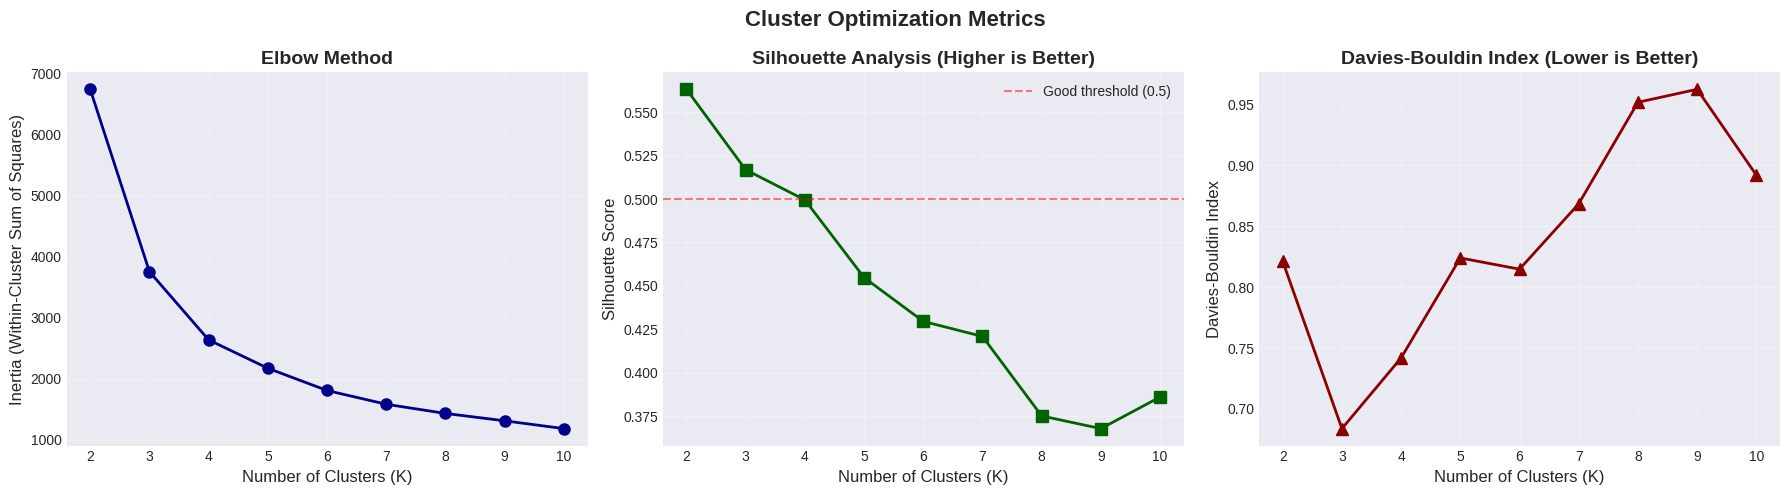


✅ Saved: 03_elbow_silhouette.png

🎯 CLUSTER SELECTION RECOMMENDATION
Best Silhouette Score: K=2 (score: 0.563)
Best Davies-Bouldin: K=3 (score: 0.684)

💡 Business Decision: Using K=4 clusters
   Rationale: Balance between statistical metrics and business interpretability


In [15]:
# %%
# ============================================================================
# SECTION 5: CLUSTERING PREPARATION & OPTIMIZATION
# ============================================================================

print("\n" + "=" * 80)
print("🎯 K-MEANS CLUSTERING PREPARATION")
print("=" * 80)

# Select features for clustering
clustering_features = ['Recency', 'Frequency', 'Monetary']
X = rfm_filtered[clustering_features].copy()

print(f"\nClustering Dataset:")
print(f"  Samples: {len(X):,}")
print(f"  Features: {clustering_features}")

# Standardize features (critical for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print(f"\n✅ Feature Scaling Complete")
print(f"   Method: StandardScaler (zero mean, unit variance)")

print("\nScaled Feature Statistics:")
print(X_scaled_df.describe().round(3))

# %%
# Determine Optimal Number of Clusters

print("\n" + "=" * 80)
print("📊 OPTIMAL CLUSTER ANALYSIS")
print("=" * 80)

# Test different cluster numbers
K_range = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("\nEvaluating cluster configurations...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}, Davies-Bouldin={davies_bouldin_scores[-1]:.3f}")

# %%
# Visualization of Clustering Metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cluster Optimization Metrics', fontsize=16, fontweight='bold')

# Elbow Method
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='darkgreen')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Good threshold (0.5)')
axes[1].legend()

# Davies-Bouldin Index
axes[2].plot(K_range, davies_bouldin_scores, marker='^', linewidth=2, markersize=8, color='darkred')
axes[2].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(K_range)

plt.tight_layout()
plt.savefig('03_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved: 03_elbow_silhouette.png")

# Recommendation
best_silhouette_k = K_range[np.argmax(silhouette_scores)]
best_db_k = K_range[np.argmin(davies_bouldin_scores)]

print("\n" + "=" * 80)
print("🎯 CLUSTER SELECTION RECOMMENDATION")
print("=" * 80)
print(f"Best Silhouette Score: K={best_silhouette_k} (score: {max(silhouette_scores):.3f})")
print(f"Best Davies-Bouldin: K={best_db_k} (score: {min(davies_bouldin_scores):.3f})")
print(f"\n💡 Business Decision: Using K=4 clusters")
print("   Rationale: Balance between statistical metrics and business interpretability")

In [16]:
# %%
# ============================================================================
# SECTION 6: FINAL K-MEANS CLUSTERING (K=4)
# ============================================================================

print("\n" + "=" * 80)
print("🚀 FINAL CLUSTERING MODEL")
print("=" * 80)

# Train final model
OPTIMAL_K = 4
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=500)
rfm_filtered['Cluster'] = final_kmeans.fit_predict(X_scaled)

print(f"✅ K-Means model trained with K={OPTIMAL_K}")
print(f"\nModel Performance:")
print(f"  Inertia: {final_kmeans.inertia_:.2f}")
print(f"  Silhouette Score: {silhouette_score(X_scaled, rfm_filtered['Cluster']):.3f}")
print(f"  Davies-Bouldin Index: {davies_bouldin_score(X_scaled, rfm_filtered['Cluster']):.3f}")

# Cluster distribution
print(f"\n📊 Cluster Distribution:")
cluster_dist = rfm_filtered['Cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    print(f"  Cluster {cluster}: {count:,} customers ({count/len(rfm_filtered)*100:.1f}%)")



🚀 FINAL CLUSTERING MODEL
✅ K-Means model trained with K=4

Model Performance:
  Inertia: 2637.45
  Silhouette Score: 0.500
  Davies-Bouldin Index: 0.742

📊 Cluster Distribution:
  Cluster 0: 2,109 customers (54.6%)
  Cluster 1: 933 customers (24.2%)
  Cluster 2: 151 customers (3.9%)
  Cluster 3: 668 customers (17.3%)


In [17]:
# %%
# ============================================================================
# SECTION 7: CLUSTER PROFILING & INTERPRETATION
# ============================================================================

print("\n" + "=" * 80)
print("📈 CLUSTER PROFILING")
print("=" * 80)

# Calculate cluster statistics
cluster_profile = rfm_filtered.groupby('Cluster').agg({
    'Recency': ['mean', 'median', 'std'],
    'Frequency': ['mean', 'median', 'std'],
    'Monetary': ['mean', 'median', 'std', 'sum'],
    'CustomerID': 'count'
}).round(2)

cluster_profile.columns = ['_'.join(col).strip() for col in cluster_profile.columns.values]
cluster_profile = cluster_profile.rename(columns={'CustomerID_count': 'Customer_Count'})

print("\nDetailed Cluster Statistics:")
print(cluster_profile)

# Calculate revenue contribution
total_revenue = rfm_filtered['Monetary'].sum()
cluster_profile['Revenue_Contribution_%'] = (cluster_profile['Monetary_sum'] / total_revenue * 100).round(2)
cluster_profile['Avg_Customer_Value'] = cluster_profile['Monetary_sum'] / cluster_profile['Customer_Count']

print("\n💰 Revenue Contribution by Cluster:")
print(cluster_profile[['Customer_Count', 'Monetary_sum', 'Revenue_Contribution_%', 'Avg_Customer_Value']].to_string())

# %%
# Business Segment Naming (based on RFM characteristics)

def assign_segment_name(row):
    """Assign business-friendly segment names based on RFM values"""
    cluster = row['Cluster']
    cluster_stats = rfm_filtered[rfm_filtered['Cluster'] == cluster]

    avg_recency = cluster_stats['Recency'].mean()
    avg_frequency = cluster_stats['Frequency'].mean()
    avg_monetary = cluster_stats['Monetary'].mean()

    # Compare to overall averages
    overall_recency = rfm_filtered['Recency'].mean()
    overall_frequency = rfm_filtered['Frequency'].mean()
    overall_monetary = rfm_filtered['Monetary'].mean()

    # Segment logic
    if avg_monetary > overall_monetary * 1.5 and avg_frequency > overall_frequency * 1.5:
        return "Champions"
    elif avg_recency > overall_recency * 1.5 and avg_frequency < overall_frequency * 0.7:
        return "At Risk / Hibernating"
    elif avg_recency < overall_recency * 0.5 and avg_frequency < overall_frequency:
        return "New Customers"
    else:
        return "Potential Loyalists"

rfm_filtered['Segment'] = rfm_filtered.apply(assign_segment_name, axis=1)

print("\n" + "=" * 80)
print("🏷️ BUSINESS SEGMENT MAPPING")
print("=" * 80)

segment_mapping = rfm_filtered.groupby(['Cluster', 'Segment']).size().reset_index(name='Count')
print(segment_mapping.to_string(index=False))

segment_summary = rfm_filtered.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(2)

segment_summary.columns = ['Customer_Count', 'Avg_Recency_Days', 'Avg_Frequency', 'Avg_Monetary_Value', 'Total_Revenue']
segment_summary['Revenue_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(2)

print("\n📊 Segment Performance Summary:")
print(segment_summary.sort_values('Total_Revenue', ascending=False).to_string())


📈 CLUSTER PROFILING

Detailed Cluster Statistics:
         Recency_mean  Recency_median  Recency_std  Frequency_mean  \
Cluster                                                              
0               49.91           40.00        37.92            2.40   
1              249.66          246.00        64.91            1.48   
2               16.66            8.00        31.69           17.16   
3               28.89           17.50        32.45            7.77   

         Frequency_median  Frequency_std  Monetary_mean  Monetary_median  \
Cluster                                                                    
0                    2.00           1.35         702.09           576.00   
1                    1.00           0.88         405.67           302.46   
2                   17.00           5.31        7864.51          7194.30   
3                    7.00           2.83        2848.54          2617.31   

         Monetary_std  Monetary_sum  Customer_Count  
Cluster          

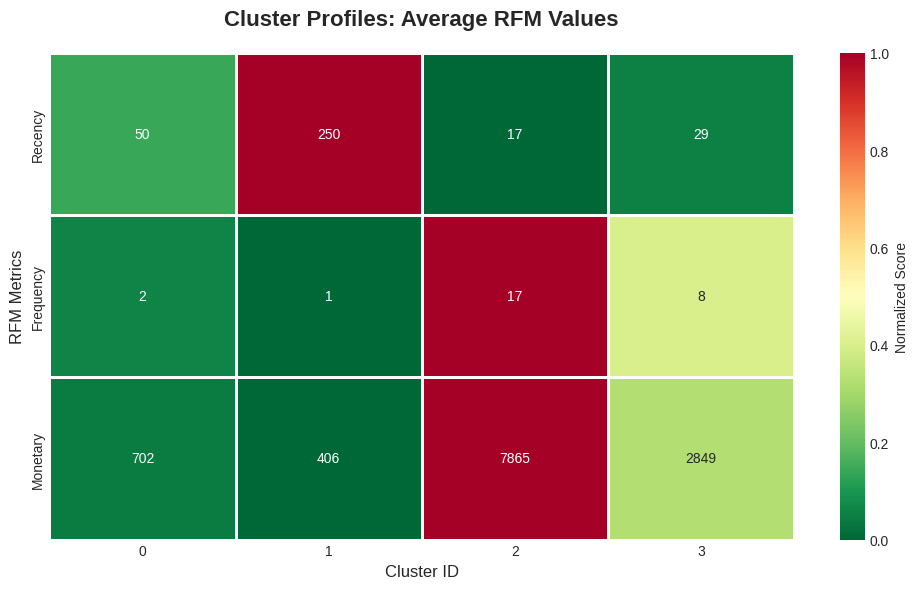

✅ Saved: 04_cluster_profiles.png


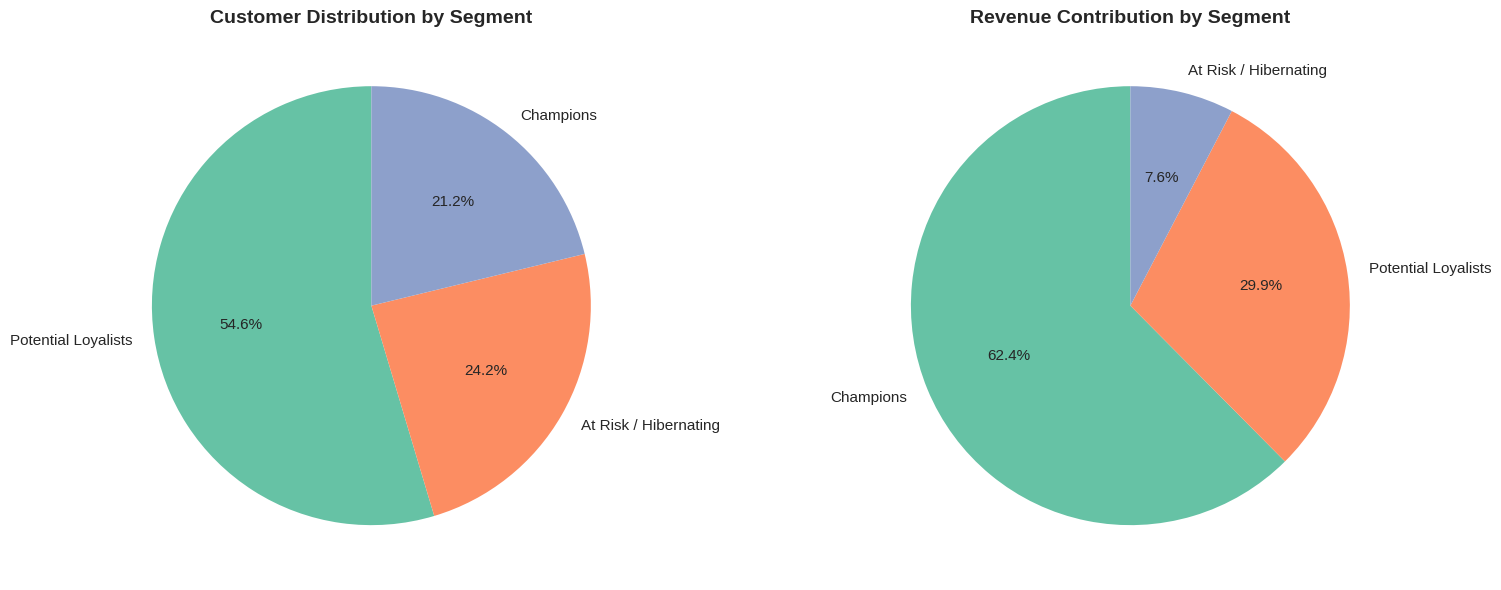

✅ Saved: 05_revenue_contribution.png


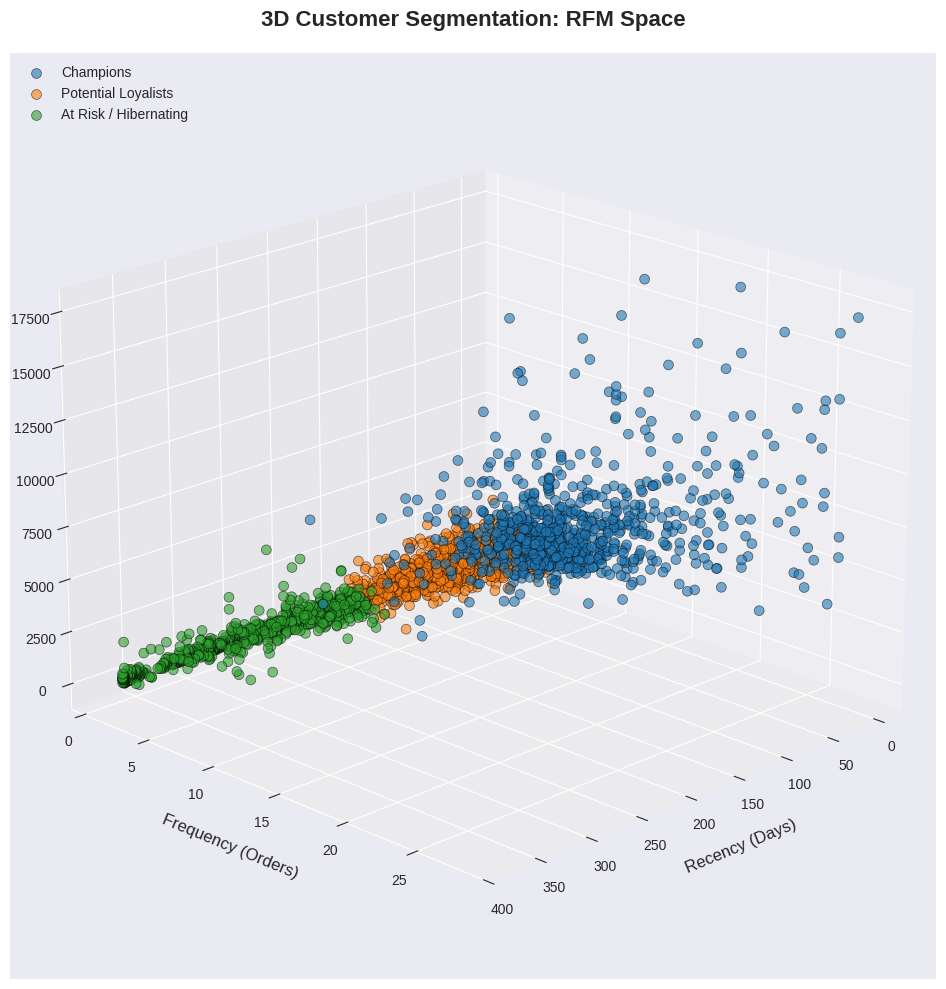

✅ Saved: 06_segment_comparison.png


In [18]:
# %%
# ============================================================================
# SECTION 8: CLUSTER VISUALIZATIONS
# ============================================================================

# Visualization 1: Cluster Profiles Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

cluster_means = rfm_filtered.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_means_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

sns.heatmap(cluster_means_normalized.T, annot=cluster_means.values.T, fmt='.0f',
            cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Score'},
            linewidths=1, linecolor='white', ax=ax)

ax.set_title('Cluster Profiles: Average RFM Values', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('RFM Metrics', fontsize=12)

plt.tight_layout()
plt.savefig('04_cluster_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 04_cluster_profiles.png")

# %%
# Visualization 2: Revenue Contribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Customer distribution
customer_counts = rfm_filtered['Segment'].value_counts()
colors = sns.color_palette('Set2', len(customer_counts))
axes[0].pie(customer_counts.values, labels=customer_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 11})
axes[0].set_title('Customer Distribution by Segment', fontsize=14, fontweight='bold')

# Revenue contribution
revenue_by_segment = rfm_filtered.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[1].pie(revenue_by_segment.values, labels=revenue_by_segment.index, autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 11})
axes[1].set_title('Revenue Contribution by Segment', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('05_revenue_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 05_revenue_contribution.png")

# %%
# Visualization 3: 3D Scatter Plot

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

segments = rfm_filtered['Segment'].unique()
colors_3d = sns.color_palette('tab10', len(segments))

for i, segment in enumerate(segments):
    segment_data = rfm_filtered[rfm_filtered['Segment'] == segment]
    ax.scatter(segment_data['Recency'], segment_data['Frequency'], segment_data['Monetary'],
               c=[colors_3d[i]], label=segment, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Recency (Days)', fontsize=12, labelpad=10)
ax.set_ylabel('Frequency (Orders)', fontsize=12, labelpad=10)
ax.set_zlabel('Monetary Value (£)', fontsize=12, labelpad=10)
ax.set_title('3D Customer Segmentation: RFM Space', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('06_segment_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: 06_segment_comparison.png")

In [19]:



# %%
# ============================================================================
# SECTION 9: BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================================================

print("\n" + "=" * 80)
print("💡 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

# Key Findings
insights = []

# Insight 1: Champions
champions = rfm_filtered[rfm_filtered['Segment'] == 'Champions']
if len(champions) > 0:
    champ_revenue_pct = (champions['Monetary'].sum() / total_revenue * 100)
    champ_customer_pct = (len(champions) / len(rfm_filtered) * 100)
    insights.append(f"""
1️⃣ CHAMPIONS - VIP Customers
   • Count: {len(champions):,} customers ({champ_customer_pct:.1f}% of base)
   • Revenue: £{champions['Monetary'].sum():,.0f} ({champ_revenue_pct:.1f}% of total)
   • Avg Purchase Frequency: {champions['Frequency'].mean():.1f} orders
   • Avg Customer Value: £{champions['Monetary'].mean():,.0f}

   💡 RECOMMENDATION:
      - Implement VIP loyalty program with exclusive rewards
      - Provide early access to new products
      - Personal account managers for top 10%
      - Request product reviews and referrals
      - Monitor closely for any decline in engagement
""")

# Insight 2: At Risk
at_risk = rfm_filtered[rfm_filtered['Segment'] == 'At Risk / Hibernating']
if len(at_risk) > 0:
    at_risk_revenue = at_risk['Monetary'].sum()
    insights.append(f"""
2️⃣ AT RISK / HIBERNATING - Churn Prevention Priority
   • Count: {len(at_risk):,} customers ({len(at_risk)/len(rfm_filtered)*100:.1f}% of base)
   • Lost Revenue Risk: £{at_risk_revenue:,.0f}
   • Avg Days Since Purchase: {at_risk['Recency'].mean():.0f} days

   💡 RECOMMENDATION:
      - Launch win-back email campaign with special discounts
      - Conduct customer feedback survey to identify pain points
      - Retarget with personalized product recommendations
      - Offer time-limited "we miss you" promotions
      - A/B test different re-engagement strategies
""")

# Insight 3: New Customers
new_customers = rfm_filtered[rfm_filtered['Segment'] == 'New Customers']
if len(new_customers) > 0:
    insights.append(f"""
3️⃣ NEW CUSTOMERS - Growth Opportunity
   • Count: {len(new_customers):,} customers ({len(new_customers)/len(rfm_filtered)*100:.1f}% of base)
   • Avg Time Since First Purchase: {new_customers['Recency'].mean():.0f} days
   • Avg Orders: {new_customers['Frequency'].mean():.1f}

   💡 RECOMMENDATION:
      - Implement onboarding email sequence (welcome series)
      - Offer second-purchase incentive within 30 days
      - Educate about product range and benefits
      - Collect preferences for personalization
      - Track conversion rate to loyal customer status
""")

# Insight 4: Potential Loyalists
potential = rfm_filtered[rfm_filtered['Segment'] == 'Potential Loyalists']
if len(potential) > 0:
    insights.append(f"""
4️⃣ POTENTIAL LOYALISTS - Upsell Opportunity
   • Count: {len(potential):,} customers ({len(potential)/len(rfm_filtered)*100:.1f}% of base)
   • Revenue: £{potential['Monetary'].sum():,.0f}
   • Avg Frequency: {potential['Frequency'].mean():.1f} orders

   💡 RECOMMENDATION:
      - Cross-sell and upsell campaigns
      - Introduce subscription or auto-replenishment options
      - Gamify purchases (points, badges, tiers)
      - Send personalized product bundles
      - Encourage social media engagement and UGC
""")

for insight in insights:
    print(insight)

# %%
# Overall Business Summary
print("\n" + "=" * 80)
print("📊 EXECUTIVE SUMMARY - KEY METRICS")
print("=" * 80)

summary_metrics = f"""
CUSTOMER BASE OVERVIEW:
• Total Customers Analyzed: {len(rfm_filtered):,}
• Total Revenue (2011): £{total_revenue:,.0f}
• Average Customer Value: £{rfm_filtered['Monetary'].mean():,.0f}
• Median Customer Value: £{rfm_filtered['Monetary'].median():,.0f}

SEGMENTATION RESULTS:
• Number of Segments: {rfm_filtered['Segment'].nunique()}
• Most Valuable Segment: {segment_summary.sort_values('Total_Revenue', ascending=False).index[0]}
• Largest Segment: {rfm_filtered['Segment'].value_counts().index[0]} ({rfm_filtered['Segment'].value_counts().values[0]} customers)

REVENUE CONCENTRATION:
• Top 20% Customers Contribute: ~{(rfm_filtered.nlargest(int(len(rfm_filtered)*0.2), 'Monetary')['Monetary'].sum() / total_revenue * 100):.1f}% of revenue
• Bottom 50% Customers Contribute: ~{(rfm_filtered.nsmallest(int(len(rfm_filtered)*0.5), 'Monetary')['Monetary'].sum() / total_revenue * 100):.1f}% of revenue

CUSTOMER BEHAVIOR:
• Avg Purchase Frequency: {rfm_filtered['Frequency'].mean():.1f} orders/year
• Avg Days Between Purchases: {rfm_filtered['AvgDaysBetweenPurchases'].mean():.0f} days
• Customer Retention Challenge: {len(at_risk):,} at-risk customers ({len(at_risk)/len(rfm_filtered)*100:.1f}%)
"""

print(summary_metrics)






💡 BUSINESS INSIGHTS & RECOMMENDATIONS

1️⃣ CHAMPIONS - VIP Customers
   • Count: 819 customers (21.2% of base)
   • Revenue: £3,090,366 (62.4% of total)
   • Avg Purchase Frequency: 9.5 orders
   • Avg Customer Value: £3,773
   
   💡 RECOMMENDATION:
      - Implement VIP loyalty program with exclusive rewards
      - Provide early access to new products
      - Personal account managers for top 10%
      - Request product reviews and referrals
      - Monitor closely for any decline in engagement


2️⃣ AT RISK / HIBERNATING - Churn Prevention Priority
   • Count: 933 customers (24.2% of base)
   • Lost Revenue Risk: £378,486
   • Avg Days Since Purchase: 250 days
   
   💡 RECOMMENDATION:
      - Launch win-back email campaign with special discounts
      - Conduct customer feedback survey to identify pain points
      - Retarget with personalized product recommendations
      - Offer time-limited "we miss you" promotions
      - A/B test different re-engagement strategies


4️⃣ POTENT

In [20]:
# %%
# ============================================================================
# SECTION 10: EXPORT RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("💾 EXPORTING RESULTS")
print("=" * 80)

# Export 1: Customer segments with RFM scores
output_df = rfm_filtered[['CustomerID', 'Recency', 'Frequency', 'Monetary',
                           'Cluster', 'Segment', 'AvgOrderValue', 'TotalItems']].copy()
output_df.to_csv('rfm_customer_segments.csv', index=False)
print("✅ Exported: rfm_customer_segments.csv")

# Export 2: Cluster summary statistics
cluster_profile.to_csv('cluster_summary_stats.csv')
print("✅ Exported: cluster_summary_stats.csv")

# Export 3: Segment summary
segment_summary.to_csv('segment_performance_summary.csv')
print("✅ Exported: segment_performance_summary.csv")

# Export 4: Business recommendations
recommendations_text = "\n".join(insights) + "\n\n" + summary_metrics

with open('business_recommendations.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("E-COMMERCE CUSTOMER SEGMENTATION - BUSINESS RECOMMENDATIONS\n")
    f.write("=" * 80 + "\n\n")
    f.write(recommendations_text)

print("✅ Exported: business_recommendations.txt")

print("\n" + "=" * 80)
print("🎉 ANALYSIS COMPLETE!")
print("=" * 80)
print("\n📁 Generated Files:")
print("   • 6 visualization images (PNG)")
print("   • 3 data exports (CSV)")
print("   • 1 recommendations report (TXT)")
print("\n🚀 Next Steps:")
print("   1. Review segment characteristics and recommendations")
print("   2. Present findings to marketing team")
print("   3. Implement targeted campaigns per segment")
print("   4. Monitor segment migration over time")
print("   5. Calculate ROI of segmentation-based marketing")


💾 EXPORTING RESULTS
✅ Exported: rfm_customer_segments.csv
✅ Exported: cluster_summary_stats.csv
✅ Exported: segment_performance_summary.csv
✅ Exported: business_recommendations.txt

🎉 ANALYSIS COMPLETE!

📁 Generated Files:
   • 6 visualization images (PNG)
   • 3 data exports (CSV)
   • 1 recommendations report (TXT)

🚀 Next Steps:
   1. Review segment characteristics and recommendations
   2. Present findings to marketing team
   3. Implement targeted campaigns per segment
   4. Monitor segment migration over time
   5. Calculate ROI of segmentation-based marketing
